In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, ScalarFormatter

In [2]:
def formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None, ncol=1):
    label_font = {'fontname': 'Arial', 'size': 14, 'color': 'black', 'weight': 'bold',
                    'labelpad': 10}
    
    legend = plt.legend(leg, frameon=False,loc=loc, bbox_to_anchor=bbox_to_anchor, ncol=ncol)
    # legend = plt.legend(leg,loc=loc, bbox_to_anchor=bbox_to_anchor, facecolor='white', framealpha=1.0)

    ax = plt.gca()
    ax.tick_params(direction='in', axis='both', which='major', pad=10)
    
    # Set the rotation and label coordinates for the fraction part
    #ax.yaxis.label.set_rotation(0)
    #ax.yaxis.set_label_coords(-0.19, 0.5)

    # Increase font size and make it bold        
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() 
                    + ax.get_yticklabels() + legend.get_texts()):
        item.set_fontsize(14)
        item.set_fontname('Arial')
        item.set_fontweight('bold')
        
    # Remove right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax.set_xlabel(xlabel, **label_font)
    ax.set_ylabel(ylabel, **label_font, rotation=90)
    
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)

    plt.tight_layout()

In [3]:
def extractDistribution(radiusData,weights,fFaz,binVolume,n,pltLabel = '_nolegend_',lineStyle = '-',markerStyle = None):


    weights = weights**1#**0.5
    vTotal = np.sum(weights)
    
    rMax = np.max(radiusData)+1e-32

    rMin = np.min(radiusData)-1e-32
    drV   = (rMax-rMin)/(n-1)
    Edges = np.zeros(shape=(n,1), dtype = float)
    fr = np.zeros(shape=(n-1,1), dtype = float)
    Edges[0]=rMin
    
    tempArray = (radiusData * fFaz)
    for ii in range(n-1):        
        #drV = drV[ii+1] - drV[ii]#binVolume[ii]
        #print(binVolume[int(ii)+1])
        rUpper = binVolume[ii+1]#rMin+(ii+1)*drV;
        rLower = binVolume[ii]#rMin+(ii)*drV;
        Edges[ii+1]= rUpper
        
        if(ii==n-2):
            rUpper=np.inf

        temp = ((tempArray >= rLower) & (tempArray < rUpper))
        #print(temp)        
        fr[ii] = np.sum(weights[temp])    
    
    rV = Edges[:n-1]+np.diff(Edges,axis=0)/2
    minrV = min(rV)

    rV = np.insert(rV, 0 ,0.0)
    fr = np.insert(fr, 0 ,0.0)
    xx = rV
    yy = fr/(vTotal)

    if(minrV>10):
        xx[0] = (minrV)/2

    return xx,yy

In [5]:
#MEMORY_DIR = "./ostrip_transient_avgPc_minPc_impP_10000"
#MEMORY_DIR = "./ostrip_transient_avgPc_avgClustPc_impP_0_D_18e9"
#MEMORY_DIR = './ostrip_transient_avgPc_avgClustPc_impP_0_D_18e9'
MEMORY_DIR =  "./ostrip_transient_avgPc_volweightedavgClustPc_impP_17500_D_1dot8minus9_H_6dot9minus6"
clustVol = np.loadtxt(os.path.join(MEMORY_DIR,'clustVolOstRipening_bent.dat'),delimiter=',')
timeArray = np.genfromtxt(os.path.join(MEMORY_DIR,'timeArrayOstRipening_bent.dat'), delimiter=',')
clustID = np.loadtxt(os.path.join(MEMORY_DIR,'clustIDOstRipening_bent.dat'),delimiter=',',dtype=int)
clustPc = np.loadtxt(os.path.join(MEMORY_DIR,'clustPcOstRipening_bent.dat'),delimiter=',')
clustMoles = np.loadtxt(os.path.join(MEMORY_DIR,'clustMolesOstRipening_bent.dat'),delimiter=',')

In [ ]:
timeArray[-2]/3600, clustPc.max()

(21.60839611111111, 40964.5)

In [6]:
notIsolatedIDS = ~((clustVol[0]==clustVol[-1])&(clustPc[0]==clustPc[-1]))
cond = ((clustVol[-1]/clustVol[0]>0.999)&(clustPc[-1]/clustPc[0]>0.999)&
        (clustPc[0]>=5000)&notIsolatedIDS)
notIsolatedIDS[cond] = False

/tmp/ipykernel_1989/987783934.py:2: RuntimeWarning: divide by zero encountered in divide
  cond = ((clustVol[-1]/clustVol[0]>0.999)&(clustPc[-1]/clustPc[0]>0.999)&
/tmp/ipykernel_1989/987783934.py:2: RuntimeWarning: invalid value encountered in divide
  cond = ((clustVol[-1]/clustVol[0]>0.999)&(clustPc[-1]/clustPc[0]>0.999)&


In [7]:
notIsolatedIDS, notIsolatedIDS.sum(), notIsolatedIDS.size, clustPc[:,notIsolatedIDS].max()

(array([ True,  True,  True, ..., False, False, False]), 2126, 2200, 160650.0)

In [8]:
# scatter plot of capillary pressure vs cluster volume at different times
for i, t in enumerate(3600*np.arange(16)):
    c = np.argmin(np.abs(timeArray[:-1]-t))
    selectedIDS = np.where((clustVol[c]>0.0)&notIsolatedIDS)[0]
    plt.scatter(clustVol[c, selectedIDS], clustPc[c, selectedIDS]/1000,
                alpha=0.7,
                edgecolors='blue')
        
    xlabel = r'Cluster volume ($m^3$)'
    ylabel = 'Capillary pressure (kPa)'
    xlim = [1e-16, 5e-10]
    ylim = [0, 90]
    plt.xscale('log')
    if i==0:
        plt.text(xlim[1]*0.1, ylim[1]*0.9, s=f'Initial', fontweight='bold')
    else:
        plt.text(xlim[1]*0.1, ylim[1]*0.9, s=f'{i} hrs', fontweight='bold')
    plt.text(xlim[1]*0.1, ylim[1]*0.85, s=f'{selectedIDS.size} clusters', fontweight='bold')
    leg = []
    formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None)
    plt.savefig(os.path.join(MEMORY_DIR, 
                            f'plots/scatterplot_pc_vol_all_{i}_hours.png'),         
                dpi=500)
    plt.close()
    #if i==5: break

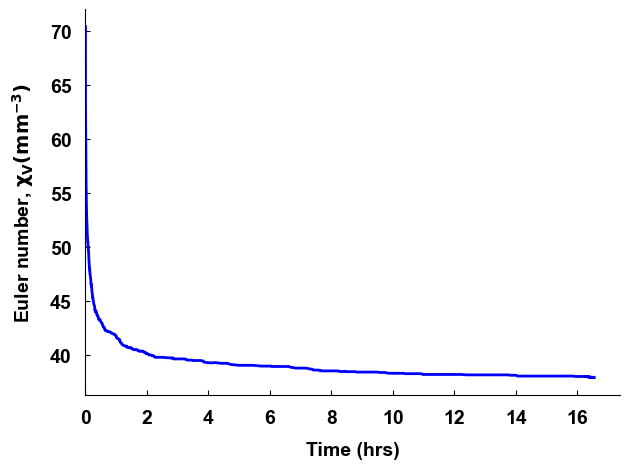

In [9]:
# euler characteristic plot
euler_char = []
timeArray = timeArray[:-1]
ptparray = np.loadtxt('pore_throat_pore_connection_bent.dat', dtype=int, delimiter=',')
elemVol = np.loadtxt('volarray_bent.dat', delimiter=',' )
fig, ax1 = plt.subplots()
bulk_volume = pow(3.0035e-3,3) #m3
#ax2 = ax1.twinx()
for j, ids in enumerate(clustID):
    #print(ids)
    cond = (ids>=0)
    cond1 = cond[ptparray]
    cond1a=(~cond1[:,0]&cond1[:,1]&~cond1[:,2])
    cond1b=(cond1[:,0]&cond1[:,1]&cond1[:,2])
    #cond1c = ((cond1[:,1]>=0)&~(cond1a|cond1b))
    euler = (cond[1:8223]).sum()+cond1a.sum()-cond1b.sum()
    euler_by_vol = euler/bulk_volume
    euler_char.append(np.array([euler, euler_by_vol]))
    
euler_char = np.array(euler_char)
fact = euler_char[0,0]/euler_char[0,1]
#ax1.plot(timeArray/3600, euler_char[:,0], label='Euler', color='blue', linewidth=2)
plt.plot(timeArray/3600, euler_char[:,1]*1e-9, label='Euler', color='blue', linewidth=2)
xlabel = 'Time (hrs)'
ylabel = 'Euler number, $\mathbf{\chi_V(mm^{-3})}$'
xlim = [0, None]
ylim = [None, None]
leg=[]
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=1, bbox_to_anchor=None)
plt.draw()
plt.savefig(os.path.join(MEMORY_DIR, f"plots/euler_characteristics_bent.png"), dpi=500)


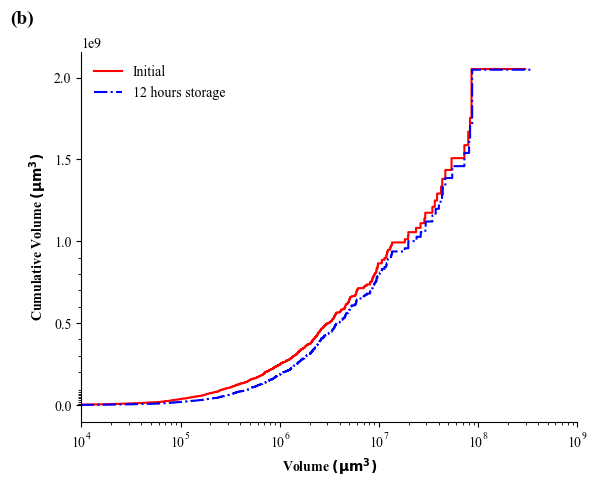

In [11]:
# Set the font family for all elements in the plot
mpl.rcParams['font.family'] = 'times new roman'

initialVol = clustVol[0]*1e18
initialVol_sort = np.sort(initialVol)
plt.step(initialVol_sort, np.cumsum(initialVol_sort),color='r',label='Initial',linestyle='-',
         marker=None)

t = 12
ind = np.argmin(np.abs(timeArray - 3600*t))
vol = clustVol[ind]*1e18
vol_sort = np.sort(vol)
plt.step(vol_sort, np.cumsum(vol_sort),color='b',label=f'{t} hours storage',linestyle='-.',
         marker=None)

# t = 12
# ind = np.argmin(np.abs(timeArray - 3600*t))
# vol = clustVol[ind]*1e18
# vol_sort = np.sort(vol)
# plt.step(vol_sort, np.cumsum(vol_sort),color='g',label=f'{t} hours storage',linestyle=':',
#          marker=None)

# t = 24
# ind = np.argmin(np.abs(timeArray - 3600*t))
# vol = clustVol[ind]*1e18
# vol_sort = np.sort(vol)
# plt.step(vol_sort, np.cumsum(vol_sort),color='y',label=f'{t} hours storage',linestyle='--',
#          marker=None)



plt.gca().set_xscale("log")
#plt.gca().set_yscale("log")
plt.xlim([1e4,1e9])
#plt.ylim([None,1])
#plt.ylim([1e5,10e10])
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))

# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


plt.legend(loc=2,frameon=False)
plt.gca().text(-0.144, 1.08, '(b)', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')

plt.xlabel('Volume $\mathbf{(\mu m^3)}$', fontweight="bold")
plt.ylabel('Cumulative Volume $\mathbf{(\mu m^3)}$', fontweight="bold")
#plt.title('$1^{st}$ Drainage', fontweight="bold")

plt.draw()
plt.savefig(os.path.join(MEMORY_DIR,f"plots/cumvol_distribution_OstRipening_bent_{t}h.png"), dpi=500)
#plt.close()

/tmp/ipykernel_1989/3306533274.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xx[0] = (minrV)/2


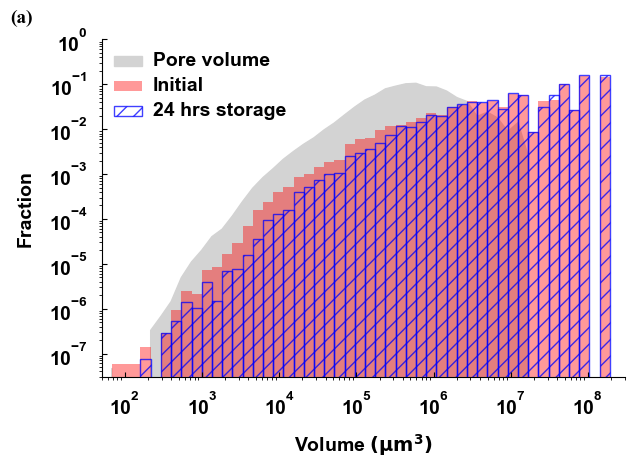

In [12]:
# Set the font family for all elements in the plot
#mpl.rcParams['font.family'] = 'times new roman'
nbinbin = 50
dV = np.logspace(start=np.log10(10e1), stop=np.log10(3e8), num=nbinbin)

elemVol = np.loadtxt('volarray_bent.dat',delimiter=',')
x,y = extractDistribution(elemVol*1e18,(elemVol)*1e18,np.ones_like(elemVol),dV,len(dV)-1)
plt.fill_between(x, y, color='lightgrey', alpha=1,label='Pore volume')

initialVol = clustVol[0]
x,y = extractDistribution(initialVol*1e18,(initialVol)*1e18,np.ones_like(initialVol),dV,len(dV)-1)
plt.hist(x, bins=x, weights=y, log=True, alpha=0.4,label='Initial',color='r')

t = 24
ind = np.argmin(np.abs(timeArray - 3600*t))
#ind = np.argmin(np.abs(timeArray - 3600*t))
vol = clustVol[ind]
x,y = extractDistribution(vol*1e18,(vol)*1e18,np.ones_like(vol),dV,len(dV)-1)
hist = plt.hist(x, bins=x, weights=y, log=True, alpha=0, edgecolor='b',facecolor='none',
                label=f'{t} days storage')
                #label=f'{t} hours storage')

for bar in hist[2]:
    bar.set_hatch('//')
    bar.set_alpha(0.75)

plt.gca().set_xscale("log")
plt.gca().set_yscale("log")
#plt.xlim([None,1e9])
plt.ylim([None,1])
#plt.ylim([1e5,10e10])
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))

# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

xlabel = 'Volume $\mathbf{(\mu m^3)}$'
ylabel = 'Fraction'
#leg = ['Pore volume', 'Initial', f'{t} days storage']
leg = ['Pore volume', 'Initial', f'{t} hrs storage']
xlim = [5e1, 3e8]
ylim = [3e-8, 1]

plt.gca().text(-0.175, 1.05, '(a)', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=None)


plt.draw()
# plt.savefig(os.path.join(MEMORY_DIR,f"plots/volweighted_distribution_OstRipening_bent_{t}d.png"), dpi=500)
plt.savefig(os.path.join(MEMORY_DIR,f"plots/volweighted_distribution_OstRipening_bent_{t}h.png"), dpi=500)
#plt.close()

[0.30561709 0.23355256 0.17893881 0.24946071 0.3651491  0.44544061
 0.55695757 0.58417942 0.91690072 0.91433361 0.7231675  1.
 0.89993506]
[0.15157789 0.17551156 0.17302283 0.26485089 0.38514058 0.46041745
 0.5676025  0.62434991 0.91690072 0.91433361 0.7231675  1.
 0.89993506]
[0.15003837 0.17371319 0.17202467 0.265943   0.3869684  0.45946194
 0.5676025  0.62434991 0.91690072 0.91433361 0.7231675  1.
 0.89993506]
[0.15003837 0.17262585 0.17202467 0.26673851 0.3869684  0.46099045
 0.5635084  0.62434991 0.91690072 0.91433361 0.7231675  1.
 0.89993506]
[0.15003837 0.17276844 0.1712647  0.26673851 0.3869684  0.46099045
 0.5635084  0.62434991 0.91690072 0.91433361 0.7231675  1.
 0.89993506]


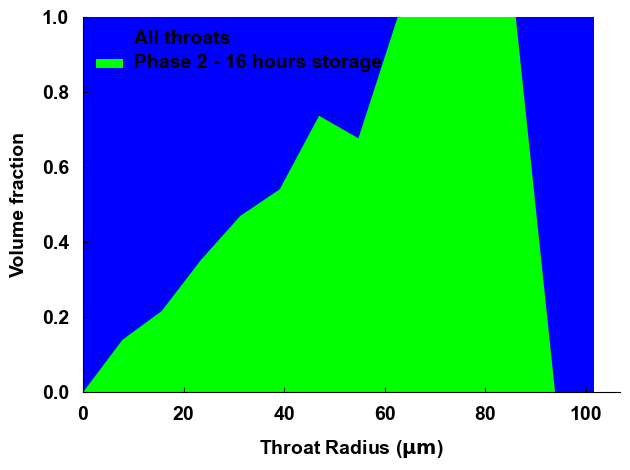

In [15]:
num_bins = 13

rarray = np.loadtxt('radiiArray_bent.dat', delimiter=',')
varray = np.loadtxt('volarray_bent.dat', delimiter=',')
bin_edges = np.linspace(rarray.min(), rarray.max(), num_bins+1)
bin_indices = np.digitize(rarray, bin_edges, right=True)

time_xh = np.array([0.0, 4*3600, 8*3600, 12*3600, 16*3600])
#time_xh = np.array([3600*24*2, 3600*24*5, 3600*24*10, 3600*24*15, 
 #                  3600*24*20, 3600*24*25, 3600*24*30]) 
indices_xh = np.argmin(np.abs(timeArray[:,None] - time_xh),axis=0)
#time_xh = time_xh/(3600*24)
time_xh = time_xh/3600

rarrayP = rarray[1:8223]
varrayP = varray[1:8223]
yP,_ = np.histogram(rarrayP, bins=bin_edges, weights=varrayP)

rarrayT = rarray[8223:-1]
varrayT = varray[8223:-1]
yT,_ = np.histogram(rarrayT, bins=bin_edges, weights=varrayT)

for i, ids in enumerate(clustID[indices_xh]):
    t = int(time_xh[i])
    plt.fill_between(bin_edges*1e6, np.ones(bin_edges.size), 0.0, color='b', edgecolor='none')
    ind = np.where(ids[:8223]>=0)[0]
    yPv,_ = np.histogram(rarrayP[ind], bins=bin_edges, weights=varrayP[ind])
    with np.errstate(divide='ignore', invalid='ignore'):
        yyP = np.divide(yPv, yP, out=np.zeros_like(yPv), where=yP != 0)
    print(yyP)
    yyP = np.insert(yyP, 0, 0.0)
    plt.fill_between(bin_edges*1e6, yyP, 0.0, color='#00ff00', alpha=1.0, edgecolor='none')
    
    if t==0:
        leg = ['All pores', f'Phase 2 - Initial']
    else:
        leg = ['All pores', f'Phase 2 - {t} hours storage']
        #leg = ['All pores', f'Phase 2 - {t} days storage']
    formatFig(r'Pore Radius ($\mathbf{\mu m}$)', r'Volume fraction', leg, 
                [0, None], [0,1.0], 2)
    
    plt.draw()

    # break
    # plt.savefig(os.path.join(
    #     MEMORY_DIR, f"gas_pore_volume_fraction_radii_distibution_bent_{t}_days.png"), dpi=500)
    plt.savefig(os.path.join(
        MEMORY_DIR, f"plots/gas_pore_volume_fraction_radii_distibution_bent_{t}_hours.png"), dpi=500)
    plt.close()

    plt.fill_between(bin_edges*1e6, np.ones(bin_edges.size), 0.0, color='b', edgecolor='none')
    ind = np.where(ids[8223:-1]>=0)[0]
    yTv,_ = np.histogram(rarrayT[ind], bins=bin_edges, weights=varrayT[ind])
    with np.errstate(divide='ignore', invalid='ignore'):
        yyT = np.divide(yTv, yT, out=np.zeros_like(yTv), where=yT != 0)
        #yyT = yTv/yT
    yyT = np.insert(yyT, 0, 0.0)
    plt.fill_between(bin_edges*1e6, yyT, 0.0, color='#00ff00', alpha=1.0, edgecolor='none')
    
    if t==0:
        leg = ['All throats', f'Phase 2 - Initial']
    else:
        leg = ['All throats', f'Phase 2 - {t} hours storage']
        #leg = ['All throats', f'Phase 2 - {t} days storage']
    formatFig(r'Throat Radius ($\mathbf{\mu m}$)', r'Volume fraction', leg, 
                [0, None], [0,1.0], 2)
    plt.draw()
    # plt.savefig(os.path.join(
    #     MEMORY_DIR, f"gas_throat_volume_fraction_radii_distibution_bent_{t}_days.png"), dpi=500)
    plt.savefig(os.path.join(
        MEMORY_DIR, f"plots/gas_throat_volume_fraction_radii_distibution_bent_{t}_hours.png"), dpi=500)
    #plt.close()

In [19]:
clustID0 = clustID[0].copy()
elemVol = np.loadtxt('volarray_bent.dat',delimiter=',')
arr = [[0, 0, 0, 0, 0]] # by number
arrVol = [[0, 0, 0, 0, 0]] # by volume
disappearance, fragmentation, normalShrink = 0, 0, 0
coalescence, normalGrowth = 0, 0
disappearance_vol, fragmentation_vol, normalShrink_vol = 0, 0, 0
coalescence_vol, normalGrowth_vol = 0, 0
timeList = [0]
n = clustVol.shape[1]
for i, ids in enumerate(clustID[1:]):
    #i+=1
    cond1a = (clustID0>=0)&(ids<0)
    cond1b = (clustID0<0)&(ids>=0)
    cond1c = np.ones(n, dtype=bool)
    # shrinkage cases
    for id in np.unique(clustID0[cond1a]):
        cond1c[id] = False
        if (clustID0==id).sum()==1:
            disappearance += 1
            disappearance_vol += clustVol[i,id]
            #disappearance_vol += float(elemVol[clustID0==id])
        else:
            newIds = np.unique(ids[clustID0==id])
            newIds = newIds[newIds>=0]
            if newIds.size>1:
                fragmentation += 1
                fragmentation_vol += (clustVol[i,id]-clustVol[i+1,newIds].sum())
                #fragmentation_vol += float(elemVol[(clustID0==id)&(ids<0)])
            else:
                normalShrink += 1
                normalShrink_vol += (float(clustVol[i,id]-clustVol[i+1,newIds]))
                #normalShrink_vol += float(elemVol[(clustID0==id)&(ids<0)])
            cond1c[newIds] = False

    # growth cases
    for id in np.unique(ids[cond1b]):
        oldIds = np.unique(clustID0[ids==id])
        oldIds = oldIds[oldIds>=0]
        cond1c[oldIds] = False
        cond1c[id] = False
        if oldIds.size>1:
            coalescence += 1
            coalescence_vol += (clustVol[i+1,id]-clustVol[i,oldIds].sum())
            #coalescence_vol += float(elemVol[(clustID0<0)&(ids==id)])
        elif oldIds.size==1:
            #print('@@',id,oldIds,clustVol[i+1,id],clustVol[i,oldIds].sum())
            normalGrowth += 1
            normalGrowth_vol += (float(clustVol[i+1,id]-clustVol[i,oldIds]))
            #normalGrowth_vol += float(elemVol[(clustID0<0)&(ids==id)])
        
    # other cases
    deltaVol = clustVol[i+1]-clustVol[i]
    cond1c1 = cond1c&(deltaVol<0.0)
    cond1c2 = cond1c&(deltaVol>0.0)
    normalShrink_vol += np.abs(deltaVol[cond1c1]).sum()
    normalGrowth_vol += deltaVol[cond1c2].sum()

    #break
    clustID0[:] = ids

    arr.append([disappearance, fragmentation, normalShrink, 
                coalescence, normalGrowth])
    arrVol.append([disappearance_vol, fragmentation_vol, normalShrink_vol,
                coalescence_vol, normalGrowth_vol])
arr = np.array(arr)
arrVol = np.array(arrVol)

/tmp/ipykernel_1989/2928328307.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  normalGrowth_vol += (float(clustVol[i+1,id]-clustVol[i,oldIds]))
/tmp/ipykernel_1989/2928328307.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  normalShrink_vol += (float(clustVol[i,id]-clustVol[i+1,newIds]))


In [18]:
clustVol[i+1,id]-clustVol[i,oldIds], oldIds

(array([], dtype=float64), array([], dtype=int64))

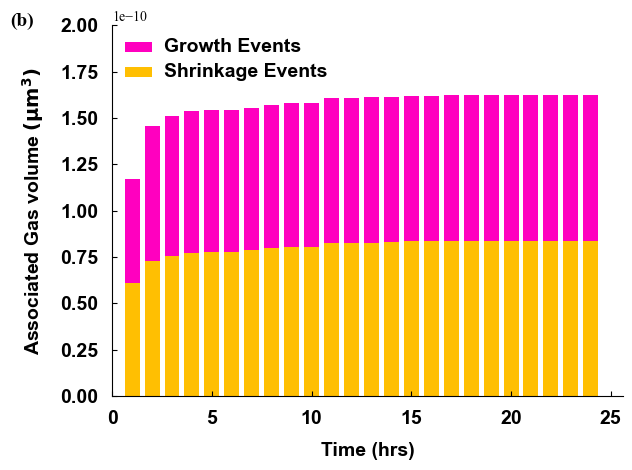

In [23]:

time_xh = np.linspace(0,3600*24, 25)
indices_xh = np.argmin(np.abs(timeArray[:,None] - time_xh),axis=0)
time_xh = time_xh/(3600)
arrVol_xh = arrVol[indices_xh]
w = 0.75

plt.bar(time_xh, arrVol_xh[:, 3]+arrVol_xh[:, 4], 
        bottom=arrVol_xh[:,0]+arrVol_xh[:,1]+arrVol_xh[:,2], 
        label='Growth events', color='#FF00BF', width=w)
plt.bar(time_xh, arrVol_xh[:,0]+arrVol_xh[:, 1]+arrVol_xh[:, 2], 
        label='Shrinkage events', 
        color='#FFBF02', width=w)


# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Set y-axis to log scale
#plt.gca().set_yscale("log")

xlabel = 'Time (hrs)'
ylabel = 'Associated Gas volume $\mathbf{(\mu m^3)}$'
xlim = [0, None]
ylim = [None, 2e-10]
#ylim = [None, None]
leg=['Growth Events', 'Shrinkage Events']

plt.gca().text(-0.2, 1, '(b)', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')
#formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=(0.5, 1.3), ncol=5)
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=(0.0, 1.0))

# Save the plot
plt.draw()
plt.savefig(os.path.join(MEMORY_DIR, f"plots/24h_Stacked_Events_Types_by_vol_OstRipening_bent.png"), dpi=500)

In [ ]:
time_xh

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24.])

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24.]
[  0 728 772 782 790 798 800 805 809 812 815 817 817 818 819 820 821 823
 823 823 823 823 823 823 823]


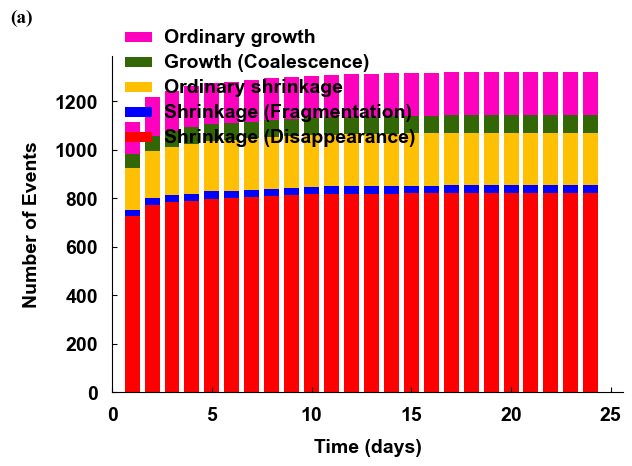

In [24]:
# Filter data for every 12-hour intervals
x = 1  # hours interval
interval = x * 3600  # 12 hours in seconds
time_xh = np.linspace(0,3600*24,int((24/x)+1))
indices_xh = np.argmin(np.abs(timeArray[:,None] - time_xh),axis=0)
time_xh = time_xh/(3600)
arr_xh = arr[indices_xh]

print(time_xh)
print(arr_xh[:,0])
w = 0.75
plt.bar(time_xh, arr_xh[:, 4], bottom=arr_xh[:,0]+arr_xh[:,1]+arr_xh[:,2]+arr_xh[:,3],
        label='Ordinary growth', color='#FF00BF', width=w)
plt.bar(time_xh, arr_xh[:, 3], bottom=arr_xh[:,0]+arr_xh[:,1]+arr_xh[:,2], 
        label='Growth (Coalescence)', color='#336605', width=w)
plt.bar(time_xh, arr_xh[:, 2], bottom=arr_xh[:,0]+arr_xh[:,1], label='Ordinary shrinkage', 
        color='#FFBF02', width=w)
plt.bar(time_xh, arr_xh[:, 1], bottom=arr_xh[:,0], label='Shrinkage (Fragmentation)',
        color='b', width=w)
plt.bar(time_xh, arr_xh[:,0], label='Shrinkage (Disappearance)', color='r', width=w)


# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

xlabel = 'Time (days)'
ylabel = 'Number of Events'
xlim = [0, None]
ylim = [0, None]
leg = ['Ordinary growth',
       'Growth (Coalescence)',
       'Ordinary shrinkage',
       'Shrinkage (Fragmentation)',
       'Shrinkage (Disappearance)']
#leg = []
plt.gca().text(-0.2, 1.1, '(a)', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')
formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=(0.0, 1.12))
#formatFig(xlabel, ylabel, leg, xlim, ylim, loc=2, bbox_to_anchor=(0.0, 1.4))

# Save the plot
plt.draw()
plt.savefig(os.path.join(MEMORY_DIR, f"24h_Stacked_Events_Types_OstRipening_bent.png"), dpi=500)

In [ ]:
time_xh

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24.])

0.726
0.5720000000000001
0.41800000000000004
0.264
0.10999999999999999


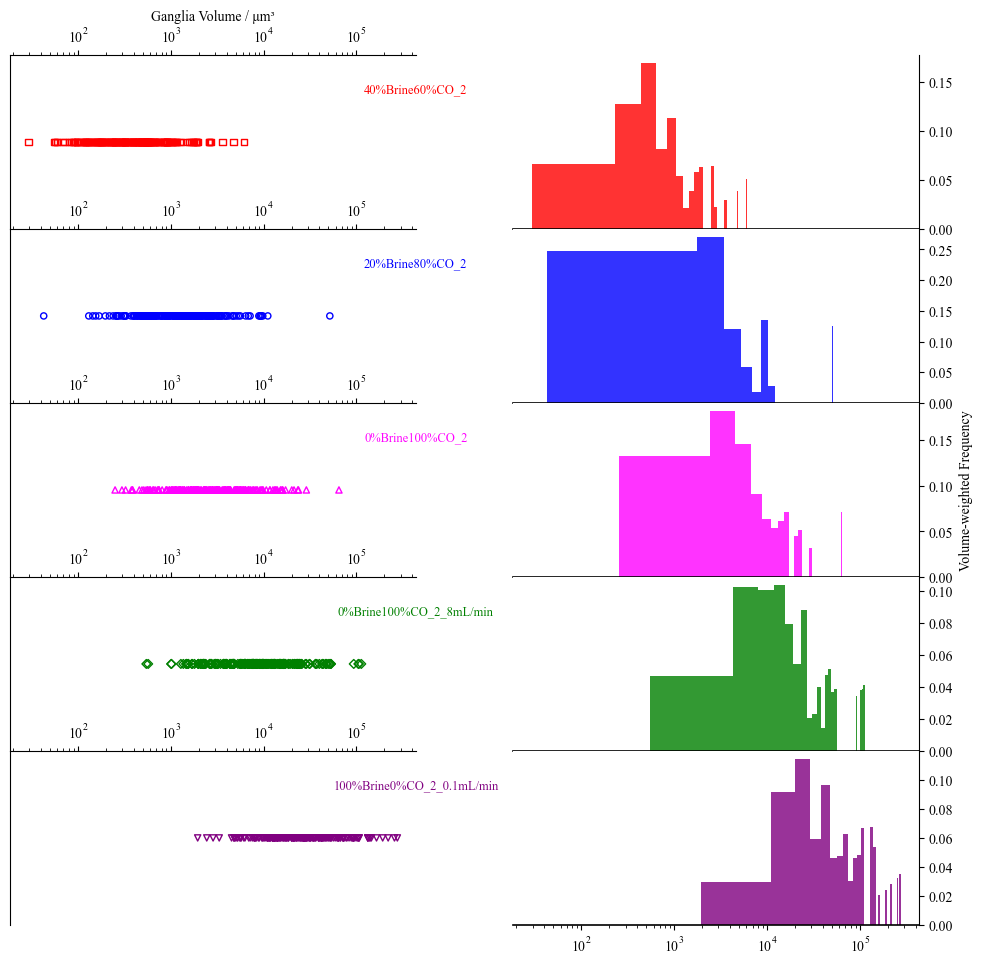

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example conditions with colors and markers
conditions = [
    ("40%Brine60%CO_2", "red", "s"),
    ("20%Brine80%CO_2", "blue", "o"),
    ("0%Brine100%CO_2", "magenta", "^"),
    ("0%Brine100%CO_2_8mL/min", "green", "D"),
    ("100%Brine0%CO_2_0.1mL/min", "purple", "v")
]

# Generate synthetic ganglia volume data
np.random.seed(42)
datasets = [np.random.lognormal(mean=6+i, sigma=1.0, size=200) for i in range(len(conditions))]

# Figure with 2 columns: left=scatter, right=hist
fig, axes = plt.subplots(n_conditions, 2, figsize=(10, 18), 
                         gridspec_kw={"width_ratios": [1,1], "hspace": 0}, sharex="col",
                         constrained_layout=False)


# Loop over datasets
for i, (label, color, marker) in enumerate(conditions):
    vols = datasets[i]
    
    # --- Left: scatter plot ---
    # axes[i, 0] = ax_left
    ax = axes[i, 0]
    
    # Scatter plot
    ax.scatter(vols, np.zeros_like(vols),  # flat horizontal line (like your figure)
               marker=marker, facecolors='none', edgecolors=color, s=20)

    # Log scale on x
    ax.set_xscale("log")

    # Hide y-ticks and add condition labels
    ax.set_yticks([])
    ax.set_ylabel(label, color=color, fontsize=9, rotation=0,
                  labelpad=50, va="center")
    ax.yaxis.set_label_coords(1.0, 0.8)

    # Keep only left and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Hide x-axis labels except top
    if i < len(conditions)-1:
        ax_scatter.tick_params(axis='x', labelbottom=False)
    else:
        ax_scatter.set_xlabel("Ganglia Volume / μm³")
    
    # --- Right: histogram ---
    ax = axes[i, 1]

     # Volume-weighted histogram
    weights = vols / np.sum(vols)
    ax.hist(vols, bins=30, weights=weights, color=color, alpha=0.8)

    # Log scale x-axis
    ax.set_xscale("log")

    # Hide left y-axis, move y-axis to the right
    ax.yaxis.tick_right()

    # Keep only bottom + right spines
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['bottom'].set_color("black")
    ax.xaxis.tick_bottom()

    # Hide x-axis labels except bottom
    if i < len(conditions)-1:
        ax_hist.tick_params(axis='x', labelbottom=False)
    else:
        ax_hist.set_xlabel("Ganglia Volume / μm³")
    
# Adjust axes sharing
# Left column: put x-axis labels at top
for ax in axes[:,0]:
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
axes[0,0].set_xlabel("Ganglia Volume / μm³")


# Right column: keep x-axis labels at bottom
for ax in axes[:,1]:
    ax.xaxis.set_ticks_position("bottom")
    ax.xaxis.set_label_position("bottom")
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0+0.5, pos.width, pos.height])
    
    print(pos.y0)

# Shared y-label for histograms
axes[len(conditions)//2, 1].set_ylabel("Volume-weighted Frequency")
axes[len(conditions)//2, 1].yaxis.set_label_position("right")


plt.tight_layout()
plt.show()


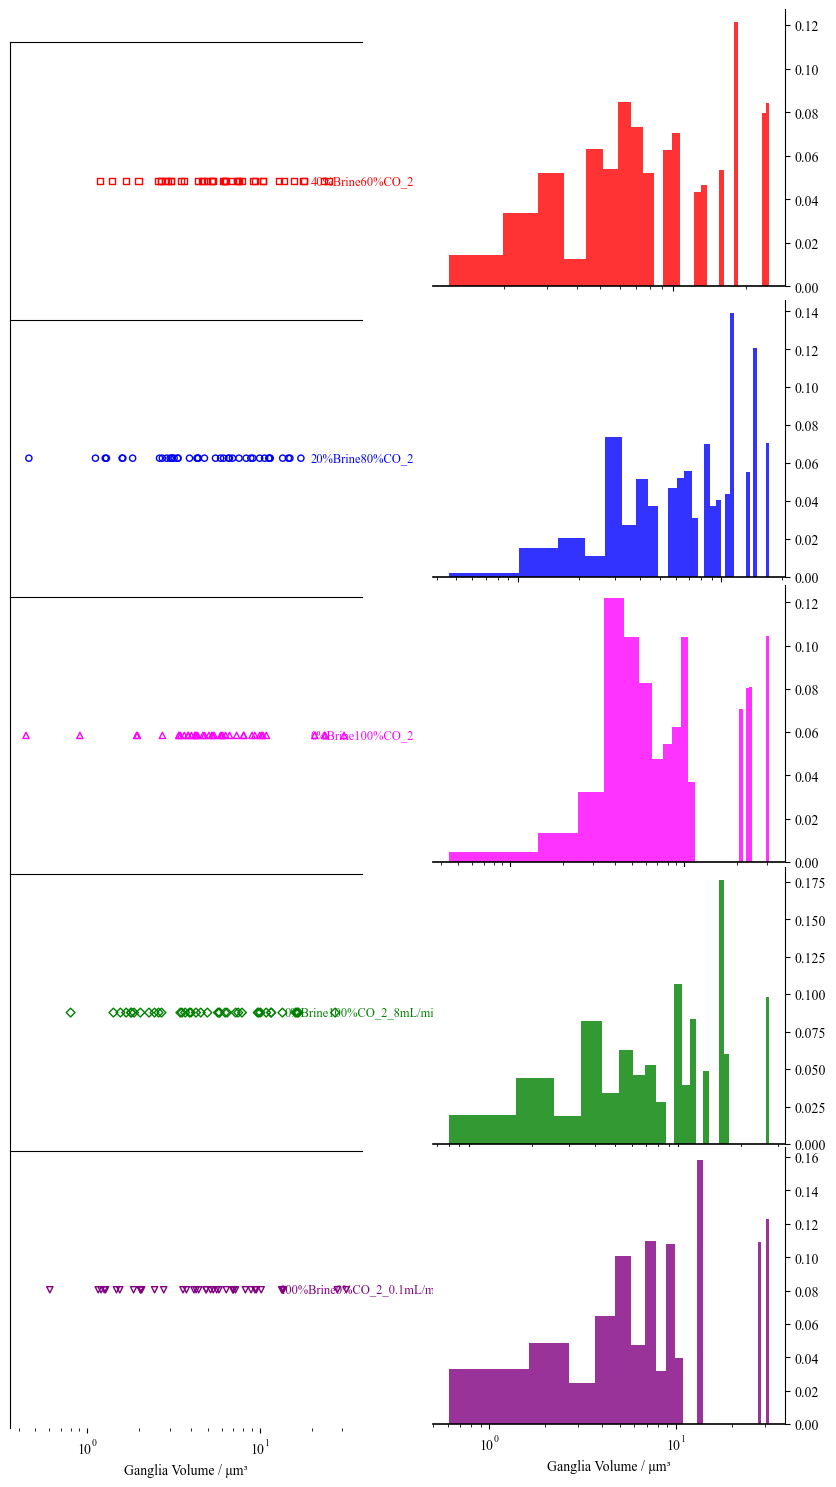

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data — replace with your real `conditions` and `datasets`
conditions = [
    ("40%Brine60%CO_2", "red", "s"),
    ("20%Brine80%CO_2", "blue", "o"),
    ("0%Brine100%CO_2", "magenta", "^"),
    ("0%Brine100%CO_2_8mL/min", "green", "D"),
    ("100%Brine0%CO_2_0.1mL/min", "purple", "v")
]

datasets = [np.random.lognormal(mean=1.5, sigma=0.8, size=40) for _ in conditions]

n_conditions = len(conditions)

# Create grid with two columns; don't use constrained_layout here (we'll manage positions manually)
fig, axes = plt.subplots(n_conditions, 2, figsize=(10, 18),
                         gridspec_kw={"width_ratios": [1, 1], "hspace": 0}, sharex="col",
                         constrained_layout=False)

# --- Plot left column (scatter) on the axes that plt.subplots created ---
for i, (label, color, marker) in enumerate(conditions):
    vols = datasets[i]

    ax_left = axes[i, 0]
    ax_left.scatter(vols, np.zeros_like(vols),
                    marker=marker, facecolors='none', edgecolors=color, s=20)
    ax_left.set_xscale("log")
    ax_left.set_yticks([])
    ax_left.set_ylabel(label, color=color, fontsize=9, rotation=0,
                       labelpad=40, va="center")
    ax_left.yaxis.set_label_coords(1.0, 0.5)  # inside the left plot
    ax_left.spines['right'].set_visible(False)
    ax_left.spines['bottom'].set_visible(False)

    if i < n_conditions - 1:
        ax_left.tick_params(axis='x', labelbottom=False)
    else:
        ax_left.set_xlabel("Ganglia Volume / μm³")

# Ensure renderer has computed initial positions
fig.canvas.draw()

# --- Replace the right-column axes with new axes shifted slightly upward ---
for i in range(n_conditions):
    old_ax = axes[i, 1]
    old_pos = old_ax.get_position()  # Bbox: x0, y0, width, height

    # desired shift relative to axes height (proportional); tweak this factor to taste
    desired_shift = old_pos.height * 0.12  # 12% of the axis height (visible but small)
    max_abs_shift = 0.03  # absolute cap in figure coords (safety)

    # compute vertical gap between this axes top and the axes above it (if any)
    if i > 0:
        above_pos = axes[i - 1, 1].get_position()
        gap = above_pos.y0 - (old_pos.y0 + old_pos.height)  # available space between top of this and bottom of above
    else:
        # for the top axis we are limited by the figure top
        gap = 1.0 - (old_pos.y0 + old_pos.height)

    # choose shift so we don't overlap above; if no positive gap, we will reduce height instead
    if gap > 1e-6:
        delta = min(desired_shift, gap * 0.6, max_abs_shift)
        new_height = old_pos.height
    else:
        # no free gap — raise the bottom and reduce height so top stays in place (safe)
        delta = min(desired_shift, old_pos.height * 0.2, max_abs_shift)
        new_height = old_pos.height - delta

    # remove the original axis and add a new one at shifted position
    old_ax.remove()
    new_pos = [old_pos.x0, old_pos.y0 + delta, old_pos.width, new_height]
    new_ax = fig.add_axes(new_pos)   # creates an independent Axes (not managed by tight_layout)
    axes[i, 1] = new_ax              # replace in the array so later code can use it

    # plot histogram on the new axis (copy your styling)
    vols = datasets[i]
    weights = vols / np.sum(vols)
    new_ax.hist(vols, bins=30, weights=weights, color=conditions[i][1], alpha=0.8)
    new_ax.set_xscale("log")
    new_ax.yaxis.tick_right()
    new_ax.spines['left'].set_visible(False)
    new_ax.spines['top'].set_visible(False)
    new_ax.spines['bottom'].set_linewidth(1.2)
    new_ax.spines['bottom'].set_color("black")
    new_ax.xaxis.tick_bottom()
    if i < n_conditions - 1:
        new_ax.tick_params(axis='x', labelbottom=False)
    else:
        new_ax.set_xlabel("Ganglia Volume / μm³")

# Do NOT call plt.tight_layout() after this (it will reposition what you manually set).
fig.canvas.draw()
plt.show()


/tmp/ipykernel_17770/4230383937.py:60: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/home/aiadebimpe/miniconda3/envs/flowmodel/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


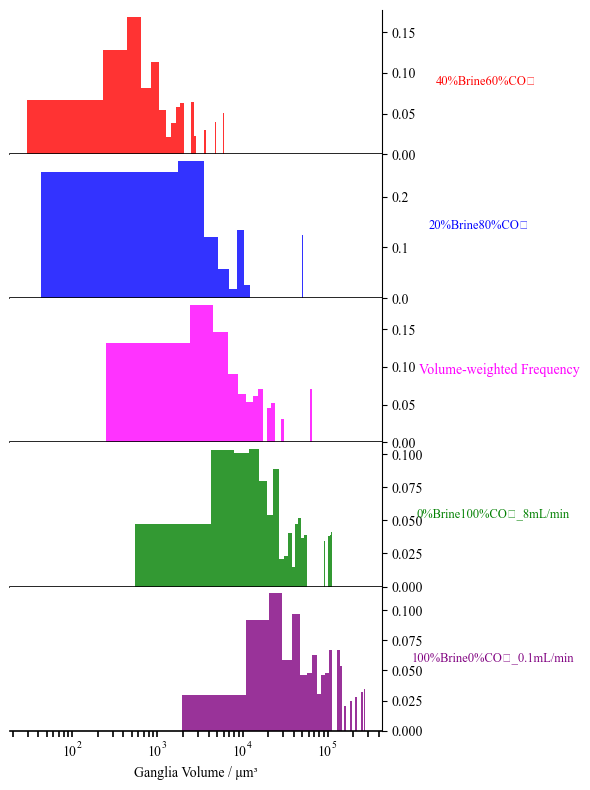

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example conditions with colors
conditions = [
    ("40%Brine60%CO₂", "red"),
    ("20%Brine80%CO₂", "blue"),
    ("0%Brine100%CO₂", "magenta"),
    ("0%Brine100%CO₂_8mL/min", "green"),
    ("100%Brine0%CO₂_0.1mL/min", "purple")
]

# Generate synthetic ganglia volume data
np.random.seed(42)
datasets = [np.random.lognormal(mean=6+i, sigma=1.0, size=200) for i in range(len(conditions))]

# Create figure with stacked histograms, no space between them
fig, axes = plt.subplots(len(conditions), 1, figsize=(6, 8),
                         sharex=True,
                         gridspec_kw={"hspace": 0})

for i, (label, color) in enumerate(conditions):
    ax = axes[i]
    vols = datasets[i]

    # Volume-weighted histogram
    weights = vols / np.sum(vols)
    ax.hist(vols, bins=30, weights=weights, color=color, alpha=0.8)

    # Log scale x-axis
    ax.set_xscale("log")

    # Move y-axis to the right
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

    # Label each subplot on the right
    ax.set_ylabel(label, color=color, fontsize=9, rotation=0,
                  labelpad=50, va="center")

    # Hide top + left spines, keep bottom + right
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Make x-axis line (bottom spine) more visible
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['bottom'].set_color("black")

    # Make ticks bold/visible
    ax.tick_params(axis='x', which='both', direction='out', length=4, width=1.2, colors='black')
    ax.xaxis.tick_bottom()

# Shared x-axis at the bottom
axes[-1].set_xlabel("Ganglia Volume / μm³")
#axes[-1].xaxis.tick_bottom()

# Shared y-axis label on the right
axes[len(conditions)//2].set_ylabel("Volume-weighted Frequency", fontsize=10, labelpad=60)

plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example conditions with colors
conditions = [
    ("40%Brine60%CO₂", "red"),
    ("20%Brine80%CO₂", "blue"),
    ("0%Brine100%CO₂", "magenta"),
    ("0%Brine100%CO₂_8mL/min", "green"),
    ("100%Brine0%CO₂_0.1mL/min", "purple")
]

# Generate synthetic ganglia volume data
np.random.seed(42)
datasets = [np.random.lognormal(mean=6+i, sigma=1.0, size=200) for i in range(len(conditions))]

# Create figure with stacked histograms, no space between them
fig, axes = plt.subplots(len(conditions), 1, figsize=(6, 8),
                         sharex=True,
                         gridspec_kw={"hspace": 0})

for i, (label, color) in enumerate(conditions):
    ax = axes[i]
    vols = datasets[i]

    # Volume-weighted histogram
    weights = vols / np.sum(vols)
    ax.hist(vols, bins=30, weights=weights, color=color, alpha=0.8)

    # Log scale x-axis
    ax.set_xscale("log")

    # Move y-axis to the right
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

    # Label each subplot on the right
    ax.set_ylabel(label, color=color, fontsize=9, rotation=0,
                  labelpad=50, va="center")

    # Hide top + left spines, keep bottom + right
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Make x-axis line (bottom spine) more visible
    ax.spines['bottom'].set_linewidth(1.2)
    ax.spines['bottom'].set_color("black")

    # Make ticks bold/visible
    ax.tick_params(axis='x', which='both', direction='out', length=4, width=1.2, colors='black')
    ax.xaxis.tick_bottom()

# Shared x-axis at the bottom
axes[-1].set_xlabel("Ganglia Volume / μm³")
#axes[-1].xaxis.tick_bottom()

# Shared y-axis label on the right
axes[len(conditions)//2].set_ylabel("Volume-weighted Frequency", fontsize=10, labelpad=60)

plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()
